<a href="https://colab.research.google.com/github/Lwckly/Learning-projects/blob/main/mapa_logisticoExp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
from IPython.display import display

In [ ]:
plt.rcParams['figure.figsize'] = (10, 4)

In [ ]:
# Definição dos mapas
def logistic_map(x, r, k = 1):
    return r * x**k * (1 - x**k)

In [ ]:
# Simulação unidimensional
def simulate_map(map_func, x0, r, k, N):
    x = np.zeros(N)
    x[0] = x0
    for n in range(1, N):
        x[n] = map_func(x[n-1], r, k)
    return x

In [ ]:
def print_lista_formatada(lista, casas_decimais=3):
    n = len(lista)
    print(f"{'Índice':>6} | {'Valor':>{8}}")
    print("-" * 20)

    def format_val(v):
        return f"{v:.{casas_decimais}f}"

    if n <= 14:
        for i, v in enumerate(lista):
            print(f"{i:>6} | {format_val(v):>8}")
    else:
        for i in range(7):
            print(f"{i:>6} | {format_val(lista[i]):>8}")
        print("  ...  |   ...")
        for i in range(n - 7, n):
            print(f"{i:>6} | {format_val(lista[i]):>8}")


In [ ]:
# Plot da evolução temporal
def plot_time_evolution(r=3.5, x0=0.1, k =1,  N=100):
    map_func = logistic_map

    x = simulate_map(map_func, x0, r, k, N)
    # print_lista_formatada(x)

    plt.figure()
    plt.plot(range(N), x, marker='o', linestyle='-')
    plt.xlabel('n')
    plt.ylabel('xₙ')
    plt.title(f'Evolução temporal - Mapa Logístico (r = {r}) (k = {k})')
    plt.grid(True)
    plt.show()

In [ ]:
def plot_logistic_diagram(r=3.5, x0=0.2, k=1, N=20):
    # Curva do mapa e reta identidade
    x_vals = np.linspace(0, 1, 500)
    y_vals = logistic_map(x_vals, r, k)

    # Iteração do ponto inicial
    x = [x0]
    for _ in range(N):
        x.append(logistic_map(x[-1], r,k))

    # Gráfico
    plt.figure(figsize=(8, 8))
    plt.plot(x_vals, y_vals, 'k', label=r'$x_{n+1} = r x_n (1 - x_n)$')
    plt.plot(x_vals, x_vals, 'g--', label=r'$x_{n+1} = x_n$')

    for i in range(N):
        # vertical
        plt.plot([x[i], x[i]], [x[i], x[i+1]], 'r', lw=1)
        # horizontal
        plt.plot([x[i], x[i+1]], [x[i+1], x[i+1]], 'r', lw=1)

    plt.title(f"Diagrama de Iteração – Mapa Logístico\nr = {r:.3f}, k = {k} x₀ = {x0:.3f}")
    plt.xlabel(r"$x_n$")
    plt.ylabel(r"$x_{n+1}$")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

In [ ]:
# Diagrama de bifurcação
def bifurcation_diagram(r_min=2.5, r_max=4.0, k = 1, x0=0.5, num_r=5000, num_iter=1000, discard=500):

    map_func = logistic_map
    default_r_min, default_r_max = 0, 4.0

    r_values = np.linspace(r_min, r_max, num_r)
    x = np.full_like(r_values, x0)

    # Descartar transientes
    for _ in range(discard):
        x = map_func(x, r_values, k)

    # Armazenar dados pós-transiente
    x_vals, r_vals = [], []
    for _ in range(50):
        x = map_func(x, r_values)
        x_vals.append(x.copy())
        r_vals.append(r_values.copy())

    # Plot
    plt.figure(figsize=(12, 6))
    for r, x_ in zip(r_vals, x_vals):
        plt.plot(r, x_, ',k', alpha=0.3)

    plt.title(f"Diagrama de Bifurcação - Mapa Logístico k = {k}")
    plt.xlabel("r")
    plt.ylabel("x")
    plt.grid(True)
    plt.show()


In [ ]:
# Interface interativa
def interactive_time_plot():
    interact(plot_time_evolution,
             r=FloatSlider(min=0.0, max=4.0, step=0.01, value=3.5, description='r'),
             k=FloatSlider(min=0.0, max=4.0, step=0.01, value=1, description='k'),
             x0=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.1, description='x₀'),
             N=IntSlider(min=10, max=500, step=10, value=100, description='Iterações'))


In [ ]:
def interactive_logistic_diagram():
    interact(plot_logistic_diagram,
             r=FloatSlider(min=0.0, max=4.0, step=0.01, value=3.5, description='r'),
             k=FloatSlider(min=0.0, max=4.0, step=0.01, value=1, description='k'),
             x0=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.2, description='x₀'),
             N=IntSlider(min=1, max=100, step=1, value=20, description='Iterações'))

In [ ]:
# Execução do notebook
print("Use a célula abaixo para explorar os mapas caóticos:")
interactive_time_plot()

Use a célula abaixo para explorar os mapas caóticos:


interactive(children=(FloatSlider(value=3.5, description='r', max=4.0, step=0.01), FloatSlider(value=0.1, desc…

In [ ]:
print("Explore o comportamento do mapa logístico iterativamente:")
interactive_logistic_diagram()

Explore o comportamento do mapa logístico iterativamente:


interactive(children=(FloatSlider(value=3.5, description='r', max=4.0, step=0.01), FloatSlider(value=0.2, desc…


Gerando diagrama de bifurcação para o mapa logístico...


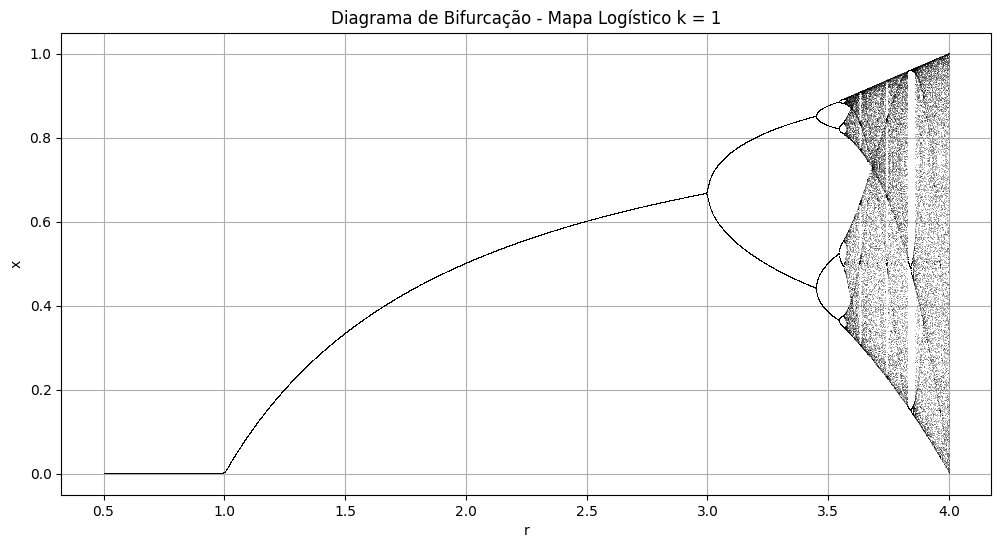

In [ ]:
# Bifurcação para mapa logístico
print("\nGerando diagrama de bifurcação para o mapa logístico...")
bifurcation_diagram(0.5, 4, 1, 0.9)